# 06. Modeling and Evaluating

## Objective

The modeling phase aims to build and evaluate a machine learning model capable of predicting the likelihood/probability of employee attrition.

Several classification algorithms will be compared to determine the model that give the best performance.

Evaluation not only use accuracy, but also precision, recall, F1-score, ROC-AUC, and PR-AUC, as the Employee Attrition dataset has class imbalance.

The modeling steps include:

1. Loading the dataset resulting from feature engineering.
2. Check the target distribution.
3. Constructing several classification models.
4. Training the models.
5. Evaluating the performance of each model.
6. Comparing model performance.
7. Performing hyperparameter tuning.
8. Performing threshold tuning if necessary.
9. Selecting the best model.
10. Saving the final model for the deployment phase.

## Import Library

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## Load Dataset

In [2]:
DATA_DIR = Path("../data/processed")

train_data = pd.read_csv(
    DATA_DIR / "train_features.csv"
)

test_data = pd.read_csv(
    DATA_DIR / "test_features.csv"
)

In [3]:
print("Train shape:", train_data.shape)
print("Test shape :", test_data.shape)

Train shape: (1176, 20)
Test shape : (294, 20)


In [4]:
train_data.head()

,num__TotalWorkingYears,num__MonthlyIncome,num__YearsAtCompany,num__JobLevel,num__YearsInCurrentRole,num__YearsWithCurrManager,num__Age,cat__OverTime_Yes,cat__JobRole_Human Resources,cat__JobRole_Laboratory Technician,cat__JobRole_Manager,cat__JobRole_Manufacturing Director,cat__JobRole_Research Director,cat__JobRole_Research Scientist,cat__JobRole_Sales Executive,cat__JobRole_Sales Representative,cat__MonthlyIncomeBracket_Low,cat__MonthlyIncomeBracket_Medium,cat__MonthlyIncomeBracket_Very High,Attrition
0,2.261482,2.026752,-0.665706,1.762189,-0.625365,-0.616406,1.090194,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
1,-1.072675,-0.864408,-0.830071,-0.986265,-0.905635,-0.897047,-1.634828,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
2,1.492061,2.347706,0.813578,1.762189,1.336527,1.348076,0.981193,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
3,-0.559727,-0.956202,-0.008246,-0.986265,-0.064824,0.506155,-1.307825,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0
4,-0.175017,-0.185956,0.156119,-0.070114,0.775986,0.786795,0.654191,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


## Split X and y

In [5]:
TARGET = "Attrition"

In [6]:
X_train = train_data.drop(columns=[TARGET])
y_train = train_data[TARGET]

X_test = test_data.drop(columns=[TARGET])
y_test = test_data[TARGET]

In [7]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (1176, 19)
y_train: (1176,)
X_test : (294, 19)
y_test : (294,)


## Evaluation Metrics

We create an evaluation function so that each model is evaluated in the same way.

In [8]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        ),
        "PR-AUC": average_precision_score(
            y_test,
            y_prob
        )
    }

    return results

## Baseline Model

For example, the model always predicts the majority class:

In [9]:
majority_class = y_train.mode()[0]
majority_class


0

In [10]:
y_baseline = np.full(shape=len(y_test), fill_value=majority_class)
y_baseline

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

In [11]:
baseline_results = {
    "Accuracy": accuracy_score(
        y_test,
        y_baseline
    ),
    "Precision": precision_score(
        y_test,
        y_baseline,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_baseline,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        y_baseline,
        zero_division=0
    )
}

baseline_results

{'Accuracy': 0.8401360544217688, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}

Evaluation results before to model implementation

This baseline serves as a minimum point of comparison.

## Logistic Regression

In [12]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

### Training

In [13]:
logistic_model.fit(
    X_train,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

### Evaluation

In [14]:
logistic_results = evaluate_model(
    logistic_model,
    X_test,
    y_test
)

logistic_results

{'Accuracy': 0.7108843537414966,
 'Precision': 0.3137254901960784,
 'Recall': 0.6808510638297872,
 'F1': 0.42953020134228187,
 'ROC-AUC': 0.7344301834783358,
 'PR-AUC': 0.4284355283411511}

## Decision Tree

In [15]:
decision_tree = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

### Training

In [16]:
decision_tree.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are 

### Evaluation

In [17]:
tree_results = evaluate_model(
    decision_tree,
    X_test,
    y_test
)

tree_results

{'Accuracy': 0.7721088435374149,
 'Precision': 0.3,
 'Recall': 0.3191489361702128,
 'F1': 0.30927835051546393,
 'ROC-AUC': 0.5887242656559565,
 'PR-AUC': 0.20458821826602983}

## Random Forest

In [18]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

### Training

In [19]:
random_forest.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

### Evaluation

In [20]:
rf_results = evaluate_model(
    random_forest,
    X_test,
    y_test
)

rf_results

{'Accuracy': 0.782312925170068,
 'Precision': 0.3023255813953488,
 'Recall': 0.2765957446808511,
 'F1': 0.28888888888888886,
 'ROC-AUC': 0.7106555258850892,
 'PR-AUC': 0.28957002396098075}

## Model Comparison

for Employee Attrition Prediction project

| Ranking | Metric        | Priority  | Why?                                                                                                                                                |
| ------- | ------------- | --------- | --------------------------------------------------------------------------------------------------------------------------------------------------- |
| 🥇 1    | **Recall**    | ⭐⭐⭐⭐⭐     | Crucial for ensuring that as many employees **actually likely to attrit** as possible are successfully detected.                                     |
| 🥈 2    | **Precision** | ⭐⭐⭐⭐⭐     | Ensures that predictions of "likely to attrit" are not frequently incorrect, preventing HR from wasting resources on false alarms.                   |
| 🥉 3    | **F1-Score**  | ⭐⭐⭐⭐      | Balances Recall and Precision. Useful when you want to avoid a model that chases Recall at the cost of generating too many false positives.         |
| 4       | **PR-AUC**    | ⭐⭐⭐⭐      | Highly relevant for **class imbalance** as it focuses on Precision–Recall performance for the Attrition class.                                      |
| 5       | **ROC-AUC**   | ⭐⭐⭐       | Measures the model's overall ability to distinguish between Attrition and No Attrition across various thresholds.                                   |
| 6       | **Accuracy**  | ⭐⭐        | Less reliable as a primary metric because the number of "No Attrition" cases usually far exceeds "Attrition" cases.                                 |


In [21]:
results = pd.DataFrame({
    "Baseline": baseline_results,
    "Logistic Regression": logistic_results,
    "Decision Tree": tree_results,
    "Random Forest": rf_results
}).T
results

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Baseline,0.840136,0.000000,0.000000,0.000000,NaN,NaN
Logistic Regression,0.710884,0.313725,0.680851,0.429530,0.734430,0.428436
Decision Tree,0.772109,0.300000,0.319149,0.309278,0.588724,0.204588
Random Forest,0.782313,0.302326,0.276596,0.288889,0.710656,0.289570


In [22]:
results.sort_values(
    by=["F1"],
    ascending=False
)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.710884,0.313725,0.680851,0.429530,0.734430,0.428436
Decision Tree,0.772109,0.300000,0.319149,0.309278,0.588724,0.204588
Random Forest,0.782313,0.302326,0.276596,0.288889,0.710656,0.289570
Baseline,0.840136,0.000000,0.000000,0.000000,NaN,NaN


## Confusion Matrix

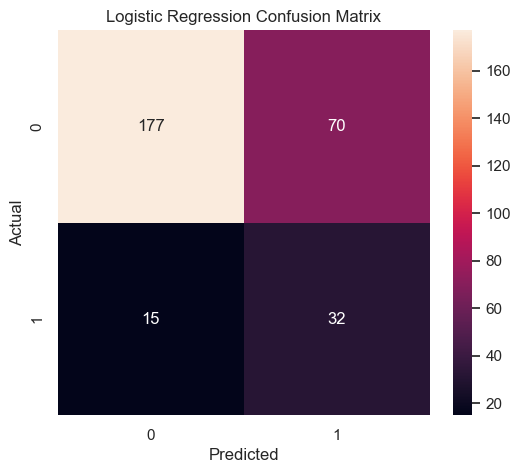

In [23]:
y_pred_lr = logistic_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
# TN  FP
# FN  TN

- TP → employees predicted to attrition who actually attrition
- FP → predicted to attrition but did not
- FN → predicted not to attrition but actually attrition
- TN → predicted not to attrition and indeed did not attrition

## ROC Curve

In [25]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest
}

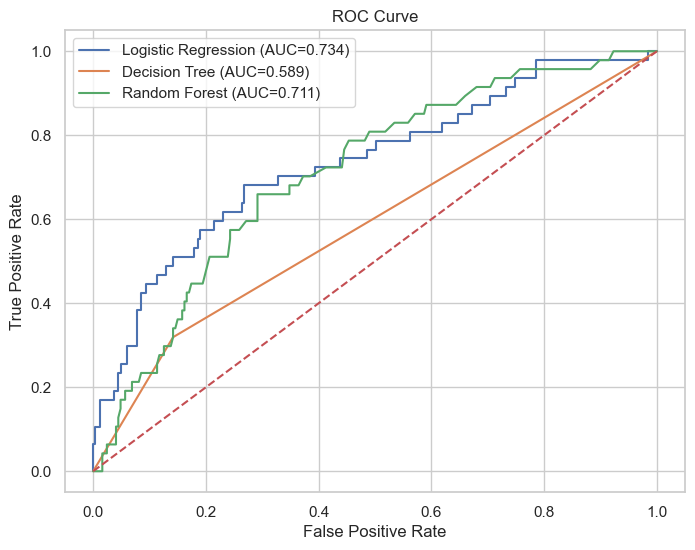

In [26]:
plt.figure(figsize=(8, 6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## Precision-Recall Curve

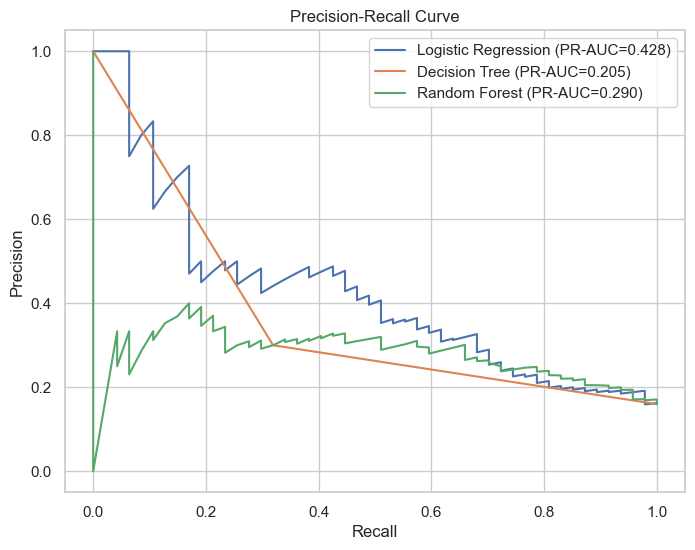

In [27]:
plt.figure(figsize=(8, 6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (PR-AUC={pr_auc:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.show()

## Hyperparameter Tuning — Logistic Regression

### Import

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

### Define Parameter Grid

Key Logistic Regression parameters requiring tuning:
- C → controls regularization strength.
- penalty → type of regularization.
- solver → optimization algorithm.
- class_weight → handles class imbalance.

In [29]:
param_grid_lr = {
    "C": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ],
    
    "penalty": [
        "l1",
        "l2"
    ],
    
    "solver": [
        "liblinear"
    ],
    
    "class_weight": [
        "balanced"
    ]
}

liblinear support L1 L2

### Stratified Cross Validation

because dataset attrition class imbalance, use StratifiedKFold, The proportions of classes 0 and 1 remain relatively balanced across each fold.

In [30]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### GridSearchCV

In [31]:
grid_lr = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    param_grid=param_grid_lr,
    
    scoring="f1",
    
    cv=cv,
    
    n_jobs=-1,
    
    verbose=1
)

In [32]:
grid_lr.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\jason\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'class_weight': ['balanced'], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_

### Viewing Best Parameters

In [33]:
print("Best Parameters:")
print(grid_lr.best_params_)

Best Parameters:
{'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}


### Best Cross-Validation Score

In [34]:
print(
    "Best CV F1:",
    grid_lr.best_score_
)

Best CV F1: 0.43305557574533954


### Select the Best Model

In [35]:
best_lr = grid_lr.best_estimator_

Now, `best_lr` is the Logistic Regression model with the best hyperparameter combination based on the F1-score.

## Evaluate Tuned Logistic Regression

In [36]:
lr_tuned_results = evaluate_model(
    best_lr,
    X_test,
    y_test
)

lr_tuned_results

{'Accuracy': 0.7074829931972789,
 'Precision': 0.3106796116504854,
 'Recall': 0.6808510638297872,
 'F1': 0.4266666666666667,
 'ROC-AUC': 0.7338272030321302,
 'PR-AUC': 0.42759189825823496}

In [37]:
lr_tuned_results_df = pd.DataFrame(
    [lr_tuned_results],
    index=["Tuned Logistic Regression"]
)

lr_tuned_results_df

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Tuned Logistic Regression,0.707483,0.31068,0.680851,0.426667,0.733827,0.427592


## Testing

In [38]:
y_pred_lr_tuned = best_lr.predict(X_test)

## Confusion Matrix

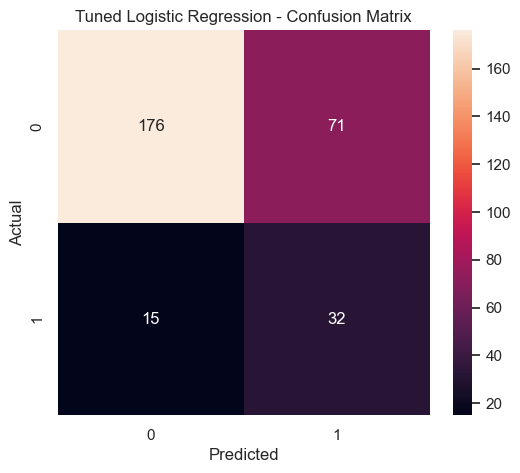

In [39]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr_tuned
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d"
)

plt.title(
    "Tuned Logistic Regression - Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Compare Before vs After Tuning

In [40]:
lr_comparison = pd.DataFrame(
    {
        "Before Tuning": logistic_results,
        "After Tuning": lr_tuned_results
    }
).T

lr_comparison

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Before Tuning,0.710884,0.313725,0.680851,0.429530,0.734430,0.428436
After Tuning,0.707483,0.310680,0.680851,0.426667,0.733827,0.427592


In [41]:
lr_comparison.sort_values(
    by="F1",
    ascending=False
)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Before Tuning,0.710884,0.313725,0.680851,0.429530,0.734430,0.428436
After Tuning,0.707483,0.310680,0.680851,0.426667,0.733827,0.427592


## Viewing All GridSearchCV Results

In [42]:
grid_lr

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'class_weight': ['balanced'], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_

In [43]:
cv_results_lr = pd.DataFrame(
    grid_lr.cv_results_
)

In [44]:
lr_grid_results = cv_results_lr[
    [
        "param_C",
        "param_penalty",
        "param_solver",
        "param_class_weight",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values(
    "rank_test_score"
)

In [45]:
lr_grid_results.head(10)

,param_C,param_penalty,param_solver,param_class_weight,mean_test_score,std_test_score,rank_test_score
7,1.000,l2,liblinear,balanced,0.433056,0.037418,1
6,1.000,l1,liblinear,balanced,0.428778,0.043936,2
10,100.000,l1,liblinear,balanced,0.422340,0.038999,3
11,100.000,l2,liblinear,balanced,0.422340,0.038999,3
5,0.100,l2,liblinear,balanced,0.420221,0.035788,5
8,10.000,l1,liblinear,balanced,0.419829,0.040630,6
9,10.000,l2,liblinear,balanced,0.419733,0.038427,7
4,0.100,l1,liblinear,balanced,0.416055,0.029379,8
3,0.010,l2,liblinear,balanced,0.377569,0.030161,9
1,0.001,l2,liblinear,balanced,0.340554,0.030434,10


You can view the 10 best hyperparameter combinations.

## Threshold Tuning for Logistic Regression

In [46]:
y_prob_lr = best_lr.predict_proba(
    X_test
)[:, 1]

In [47]:
threshold_results_lr = []

thresholds = np.arange(
    0.10,
    0.95,
    0.05
)

for threshold in thresholds:

    y_pred = (
        y_prob_lr >= threshold
    ).astype(int)

    threshold_results_lr.append({
        "Threshold": threshold,

        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        )
    })

In [48]:
threshold_lr_df = pd.DataFrame(
    threshold_results_lr
)

threshold_lr_df

,Threshold,Precision,Recall,F1
0,0.10,0.168498,0.978723,0.287500
1,0.15,0.178988,0.978723,0.302632
2,0.20,0.186441,0.936170,0.310954
3,0.25,0.195980,0.829787,0.317073
4,0.30,0.206522,0.808511,0.329004
5,0.35,0.228395,0.787234,0.354067
6,0.40,0.244604,0.723404,0.365591
7,0.45,0.266129,0.702128,0.385965
8,0.50,0.310680,0.680851,0.426667
9,0.55,0.337500,0.574468,0.425197


## Find the Best Threshold

In [49]:
best_threshold_lr = threshold_lr_df.loc[
    threshold_lr_df["F1"].idxmax()
]

best_threshold_lr

Threshold    0.650000
Precision    0.440000
Recall       0.468085
F1           0.453608
Name: 11, dtype: float64

In [50]:
threshold_lr = best_threshold_lr["Threshold"]

print(
    "Best Logistic Regression Threshold:",
    threshold_lr
)

Best Logistic Regression Threshold: 0.6500000000000001


## Final Logistic Regression Prediction

In [51]:
y_pred_lr_final = (
    y_prob_lr >= threshold_lr
).astype(int)

In [52]:
final_lr_results = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred_lr_final
    ),

    "Precision": precision_score(
        y_test,
        y_pred_lr_final,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        y_pred_lr_final,
        zero_division=0
    ),

    "F1": f1_score(
        y_test,
        y_pred_lr_final,
        zero_division=0
    ),

    "ROC-AUC": roc_auc_score(
        y_test,
        y_prob_lr
    ),

    "PR-AUC": average_precision_score(
        y_test,
        y_prob_lr
    )
}

pd.DataFrame(
    [final_lr_results],
    index=["Final Logistic Regression"]
)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Final Logistic Regression,0.819728,0.44,0.468085,0.453608,0.733827,0.427592


## Compare Logistic Regression with Other Models

In [53]:
model_comparison = pd.DataFrame({
    "Logistic Regression": final_lr_results,
    "Decision Tree": tree_results,
    "Random Forest": rf_results
}).T
model_comparison.sort_values(
    by="F1",
    ascending=False
)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.819728,0.440000,0.468085,0.453608,0.733827,0.427592
Decision Tree,0.772109,0.300000,0.319149,0.309278,0.588724,0.204588
Random Forest,0.782313,0.302326,0.276596,0.288889,0.710656,0.289570


## Save Final Model

In [54]:
from pathlib import Path
import joblib

MODEL_DIR = Path("../models")

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [55]:
best_lr = grid_lr.best_estimator_

In [56]:
joblib.dump(
    best_lr,
    MODEL_DIR / "logistic_regression_attrition.pkl"
)

['..\\models\\logistic_regression_attrition.pkl']

In [57]:
joblib.dump(
    threshold_lr,
    MODEL_DIR / "logistic_regression_threshold.pkl"
)

['..\\models\\logistic_regression_threshold.pkl']

In [58]:
best_params_lr = grid_lr.best_params_

best_params_lr

{'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

In [59]:
joblib.dump(
    best_params_lr,
    MODEL_DIR / "logistic_regression_best_params.pkl"
)

['..\\models\\logistic_regression_best_params.pkl']

In [60]:
lr_grid_results.to_csv(
    MODEL_DIR / "logistic_regression_cv_results.csv",
    index=False
)

In [61]:
final_lr_results_df = pd.DataFrame(
    [final_lr_results],
    index=["Logistic Regression"]
)

final_lr_results_df

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.819728,0.44,0.468085,0.453608,0.733827,0.427592


In [62]:
final_lr_results_df.to_csv(
    MODEL_DIR / "logistic_regression_evaluation.csv"
)

## Test Load Model

In [63]:
loaded_lr = joblib.load(
    MODEL_DIR / "logistic_regression_attrition.pkl"
)

In [64]:
loaded_threshold = joblib.load(
    MODEL_DIR / "logistic_regression_threshold.pkl"
)

In [65]:
print("Model berhasil di-load.")
print("Threshold:", loaded_threshold)

Model berhasil di-load.
Threshold: 0.6500000000000001


In [66]:
loaded_prob = loaded_lr.predict_proba(
    X_test
)[:, 1]

In [67]:
loaded_pred = (
    loaded_prob >= loaded_threshold
).astype(int)

In [68]:
print(
    "Prediksi sama:",
    np.array_equal(
        y_pred_lr_final,
        loaded_pred
    )
)

Prediksi sama: True


## Final Pipeline

In [69]:
import pandas as pd
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# =========================
# 1. Load clean data
# =========================
data = pd.read_csv("../data/clean/clean_employee_attrition.csv")

X = data.drop(columns=["Attrition"])
y = data["Attrition"].map({"No": 0, "Yes": 1})

# =========================
# 2. Train-test split
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 3. Identify feature types
# =========================
numeric_features = [
     'TotalWorkingYears',
     'MonthlyIncome',
     'YearsAtCompany',
     'JobLevel',
     'YearsInCurrentRole',
     'YearsWithCurrManager',
     'Age'
]

categorical_features = [
     'OverTime',
     'JobRole',
     'MonthlyIncomeBracket'
]

# =========================
# 4. Preprocessing
# =========================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# =========================
# 5. Tuned Logistic Regression
# =========================
best_lr = best_lr

# =========================
# 6. Combine preprocessing + model
# =========================
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_lr)
])

# =========================
# 7. Train
# =========================
final_pipeline.fit(
    X_train_raw,
    y_train
)

# =========================
# 8. Save pipeline
# =========================
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    final_pipeline,
    MODEL_DIR / "logistic_regression_pipeline.pkl"
)

print("Pipeline berhasil disimpan.")

Pipeline berhasil disimpan.


C:\Users\jason\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [70]:
best_params_lr

{'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}